face processing code, essentially pain.py split into jupyter notebook cells to reduce compute time

In [1]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA 

In [2]:
video_paths = [
    "OV5640VideoCapture/15sJonatan1.mp4",
    "OV5640VideoCapture/15sJonatan2.mp4",
    "OV5640VideoCapture/15sJonatan3.mp4",
    "OV5640VideoCapture/15sSydney1.mp4", 
    "OV5640VideoCapture/15sSydney2.mp4",
    "OV5640VideoCapture/15sSydney3.mp4"
]
video_data = {}
first_frames = {}
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

We are using OpenCV to detect the Face ROI - in practice, we will have a fixed ROI. One coould potentially use color thresholding for face detection on FPGA, but we aren't touching that right now

In [290]:
# ---- videos and compute average RGB in ROI (center of face only) ----
for idx, path in enumerate(video_paths, start=1):
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        print(f"Could not open {path}")
        continue

    reds, greens, blues = [], [], []
    last_face = None
    first_face_frame = None
    stored_sample_region = None  # for drawing later

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))

        if len(faces) > 0:
            x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
            last_face = (x, y, w, h)

            if first_face_frame is None:
                first_face_frame = frame.copy()

        elif last_face is not None:
            x, y, w, h = last_face
        else:
            continue

        cx = x + w//8
        cy = y + h // 2
        cw = w - w//4
        ch = h // 3
        sample_roi = frame[cy:cy+ch, cx:cx+cw]

        if stored_sample_region is None:
            stored_sample_region = (cx, cy, cw, ch)

        #take average from sub-ROI
        frame_rgb = cv2.cvtColor(sample_roi, cv2.COLOR_BGR2RGB)
        reds.append(np.mean(frame_rgb[:, :, 0]))
        greens.append(np.mean(frame_rgb[:, :, 1]))
        blues.append(np.mean(frame_rgb[:, :, 2]))

    cap.release()
    video_name = f"video{idx}"
    video_data[video_name] = {"R": reds, "G": greens, "B": blues}

    # displaying first fram
    if first_face_frame is not None and stored_sample_region is not None:
        x, y, w, h = last_face
        cx, cy, cw, ch = stored_sample_region

        annotated = first_face_frame.copy()
        cv2.rectangle(annotated, (x, y), (x+w, y+h), (0, 255, 0), 2)       
        cv2.rectangle(annotated, (cx, cy), (cx+cw, cy+ch), (255, 0, 0), 2) 
        first_frames[video_name] = annotated


Display the ROI and selecting region

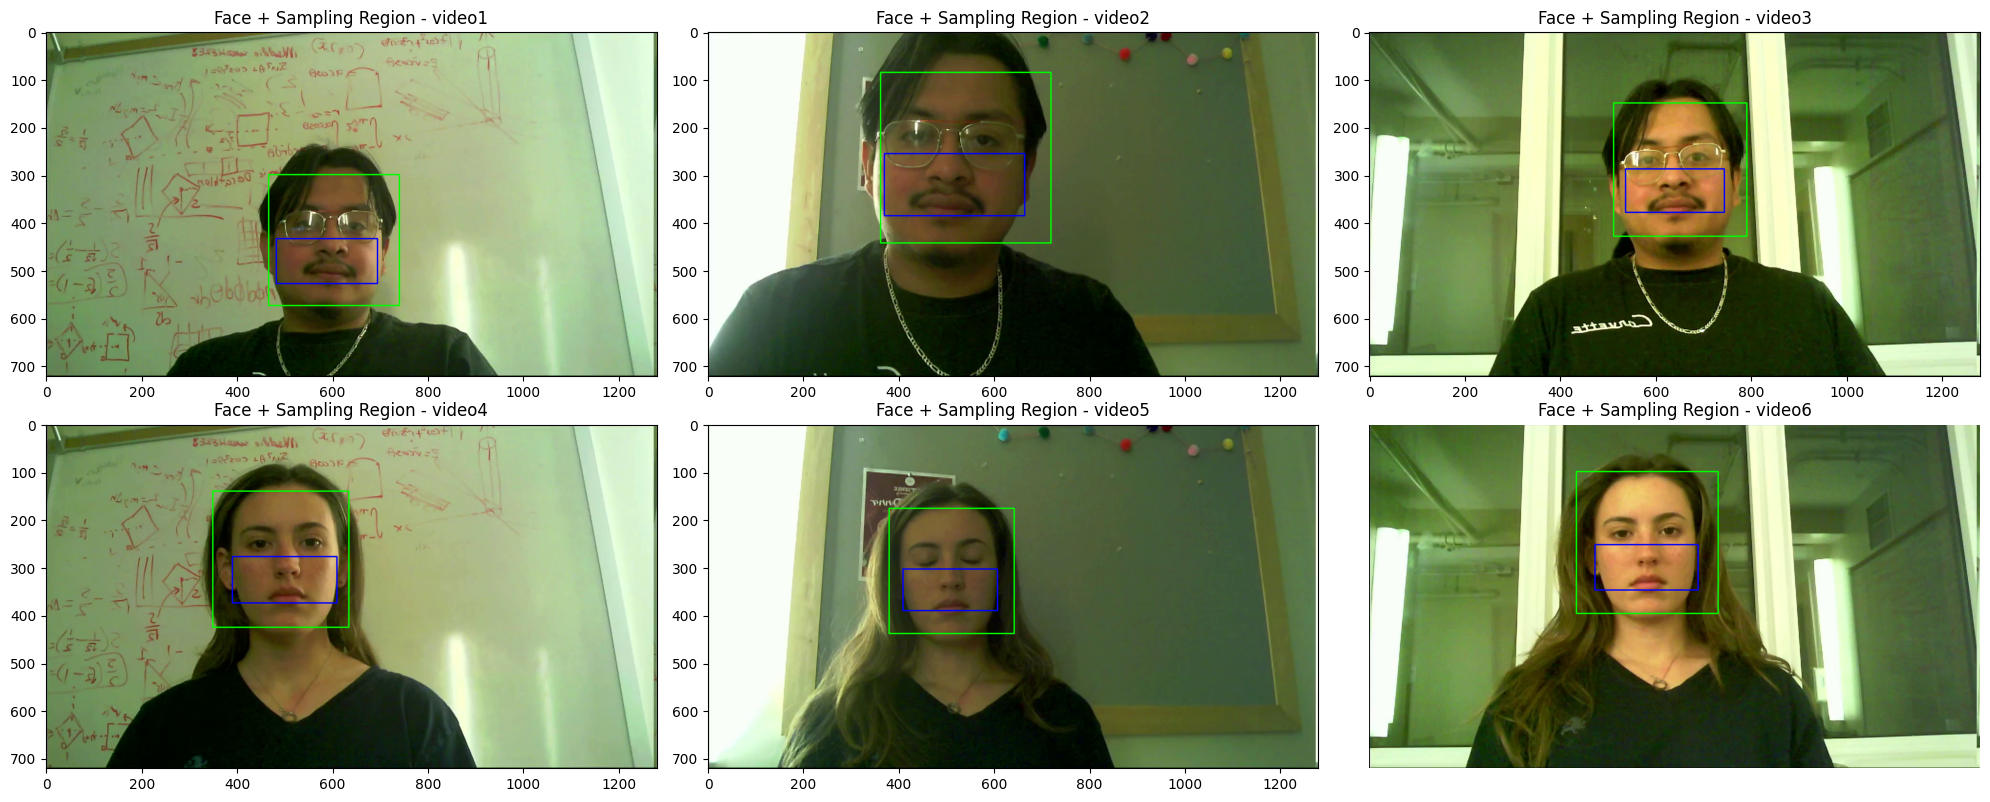

In [291]:
fig, axes = plt.subplots(2, 3, figsize=(20, 8))
axes = axes.flatten() 

for i, (name, frame) in enumerate(first_frames.items()):
    ax = axes[i]
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Face + Sampling Region - {name}")

plt.tight_layout()
plt.axis("off")
plt.show()

In [534]:
#Pre-stack all RGB data once 
total_len = sum(len(v["R"]) for v in video_data.values())
combined_rgb = np.empty((total_len, 3), dtype=float)

idx = 0
for v in video_data.values():
    n = len(v["R"])
    combined_rgb[idx:idx+n, 0] = v["R"]
    combined_rgb[idx:idx+n, 1] = v["G"]
    combined_rgb[idx:idx+n, 2] = v["B"]
    idx += n

#Train ICA on the whole dataset 
ica = FastICA(
    n_components=3,
    max_iter=10000,
    fun = 'cube',
    whiten_solver= "eigh",
    tol=1e-12)

S_all = ica.fit_transform(combined_rgb)

# A_global = ica.mixing_
# W_global = ica.components_
A_global = np.array([[-37.69225757,  -6.15255063,  -8.0652103 ], 
                     [-22.19037973,  -4.67915104,  -5.31281613], 
                     [-10.76099224,  -2.12532615,  -6.0617701 ]])

W_global = np.array([[-0.12029778,  0.14201219,  0.03559064], 
                     [ 0.54497371, -0.99840553,  0.14995908], 
                     [ 0.02248132,  0.09794917, -0.280727  ]])

# A_global = np.array([[-0.17024331,  0.06510757, -0.97322254], 
#                      [-0.19117845, -0.05581499, -0.55514838], 
#                      [-0.20174792,  0.10633008 ,-0.2525221 ]])

# W_global = np.array([[ 3.25821655, -3.87838174, -4.03090429], 
#                      [ 2.83936322, -6.83316945,  4.07920995], 
#                      [-1.40751524,  0.22130347,  0.97801058]])

print(ica.n_iter_)
print("\nShared ICA Mixing Matrix (3x3):\n", A_global)
print("\nShared ICA Unmixing Matrix (3x3):\n", W_global)

ica_results = {}

for name, data in video_data.items():
    X = np.column_stack((data["R"], data["G"], data["B"]))
    S_ica = X @ W_global.T   # much faster than ica.transform(X)
    ica_results[name] = S_ica

711

Shared ICA Mixing Matrix (3x3):
 [[-37.69225757  -6.15255063  -8.0652103 ]
 [-22.19037973  -4.67915104  -5.31281613]
 [-10.76099224  -2.12532615  -6.0617701 ]]

Shared ICA Unmixing Matrix (3x3):
 [[-0.12029778  0.14201219  0.03559064]
 [ 0.54497371 -0.99840553  0.14995908]
 [ 0.02248132  0.09794917 -0.280727  ]]


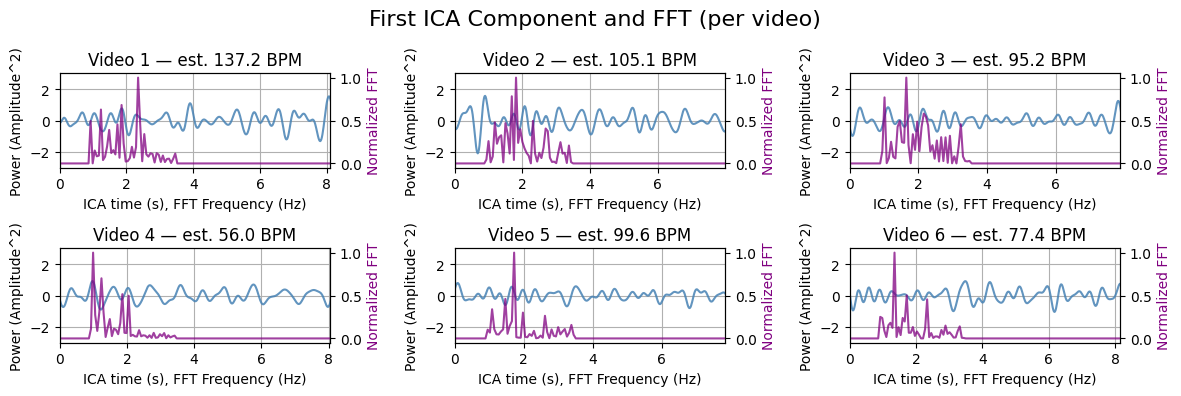

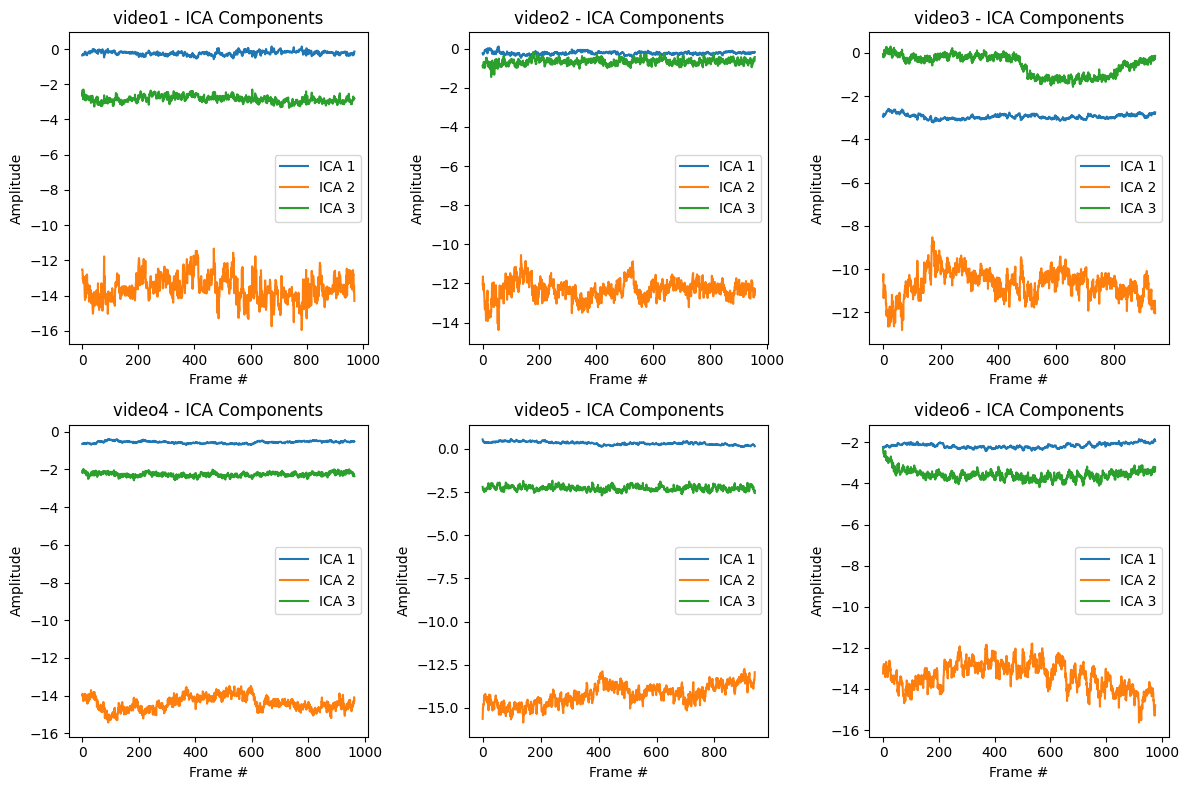

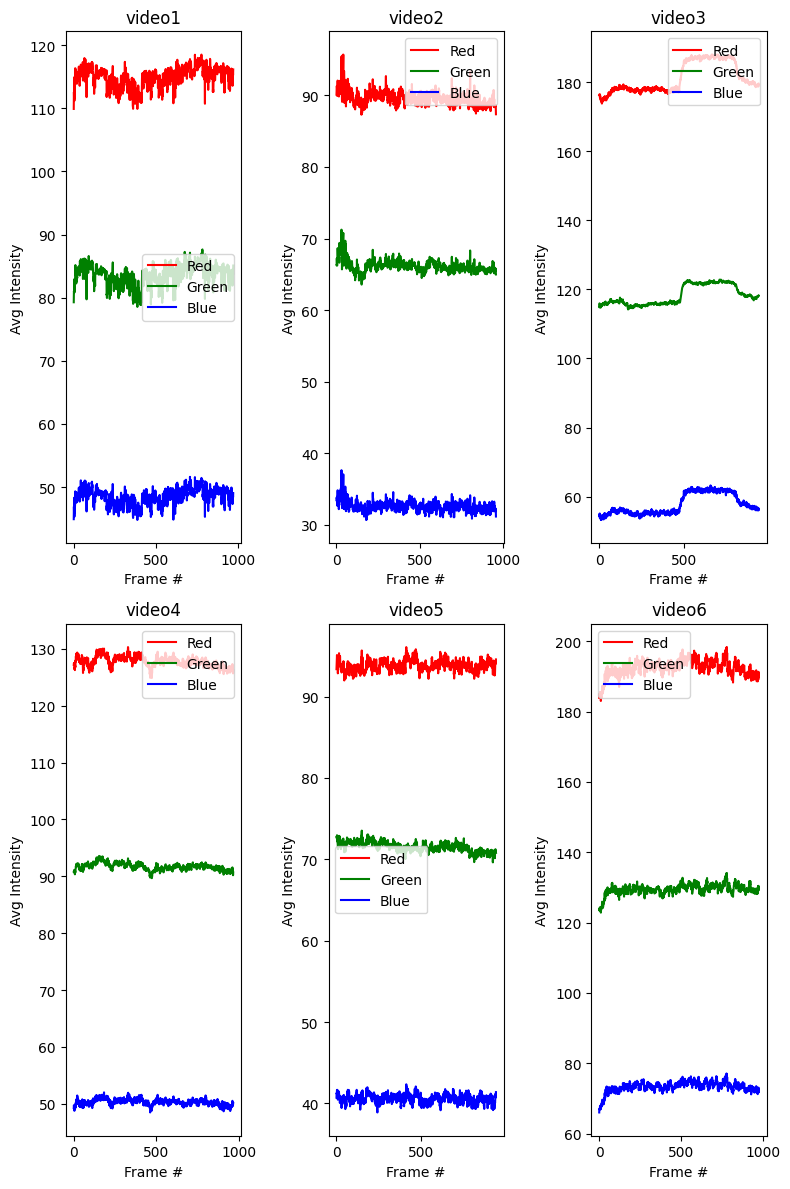

In [ ]:
ica_signals_list = [signals[:, 0] for signals in ica_results.values()]
lowcut = 0.9  
highcut = 3.5  # 210 bpm
fps = 60

fig, axs = plt.subplots(2, 3, figsize=(12, 4))
fig.suptitle("First ICA Component and FFT (per video)", fontsize=16)

for i, signal in enumerate(ica_signals_list):
    n = len(signal)
    t = np.arange(n) / fps
    freq = np.fft.rfftfreq(n, d=1/fps)

    sig = signal - np.mean(signal)
    sig /= np.std(sig) if np.std(sig) != 0 else 1
    # sig *= np.hamming(n)

    fft_sig = np.fft.rfft(sig)

    # do bandpass in the frequency domain (bc it easier)
    mask = (freq >= lowcut) & (freq <= highcut)
    fft_filt = fft_sig * mask

    # ifft to plot filtered ica signal
    sig_filt = np.fft.irfft(fft_filt, n=n)

    #  we are using the power spectrum for better peak detection
    fft_mag = np.abs(fft_filt)
    fft_mag *= fft_mag
    fft_mag /= np.max(fft_mag) if np.max(fft_mag) != 0 else 1

    dominant_freq = freq[np.argmax(fft_mag[1:])]  # skip DC bin
    bpm = dominant_freq * 60

    row, col = divmod(i, 3)

    # Time-domain plot (filtered ICA signal)
    axs[row, col].plot(t, sig_filt, color="steelblue", alpha=0.85)
    axs[row, col].set_xlim(0, n/120)  
    axs[row, col].set_ylim(-3, 3) 
    axs[row, col].set_xlabel("ICA time (s), FFT Frequency (Hz)")
    axs[row, col].set_ylabel("Power (Amplitude^2)")
    axs[row, col].set_title(f"Video {i+1} — est. {bpm:.1f} BPM")

    # FFT plot
    ax2 = axs[row, col].twinx()
    ax2.plot(freq, fft_mag, color="purple", alpha=0.75)
    ax2.set_ylabel("Normalized FFT", color="purple")

    axs[row, col].grid(True)


plt.tight_layout()
plt.show()

# ICA components for all vids
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, (name, S_ica) in enumerate(ica_results.items()):
    ax = axes[i]
    ax.plot(S_ica[:, 0], label='ICA 1')
    ax.plot(S_ica[:, 1], label='ICA 2')
    ax.plot(S_ica[:, 2], label='ICA 3')
    ax.set_title(f"{name} - ICA Components")
    ax.set_xlabel("Frame #")
    ax.set_ylabel("Amplitude")
    ax.legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(8, 12))
axes = axes.flatten()  # flatten 2x2 array into list for easy iteration

for i, (name, data) in enumerate(video_data.items()):
    ax = axes[i]
    ax.plot(data["R"], color='r', label='Red')
    ax.plot(data["G"], color='g', label='Green')
    ax.plot(data["B"], color='b', label='Blue')
    ax.set_title(f"{name}")
    ax.set_xlabel("Frame #")
    ax.set_ylabel("Avg Intensity")
    ax.legend()

# Remove any empty subplots (if <4 videos)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

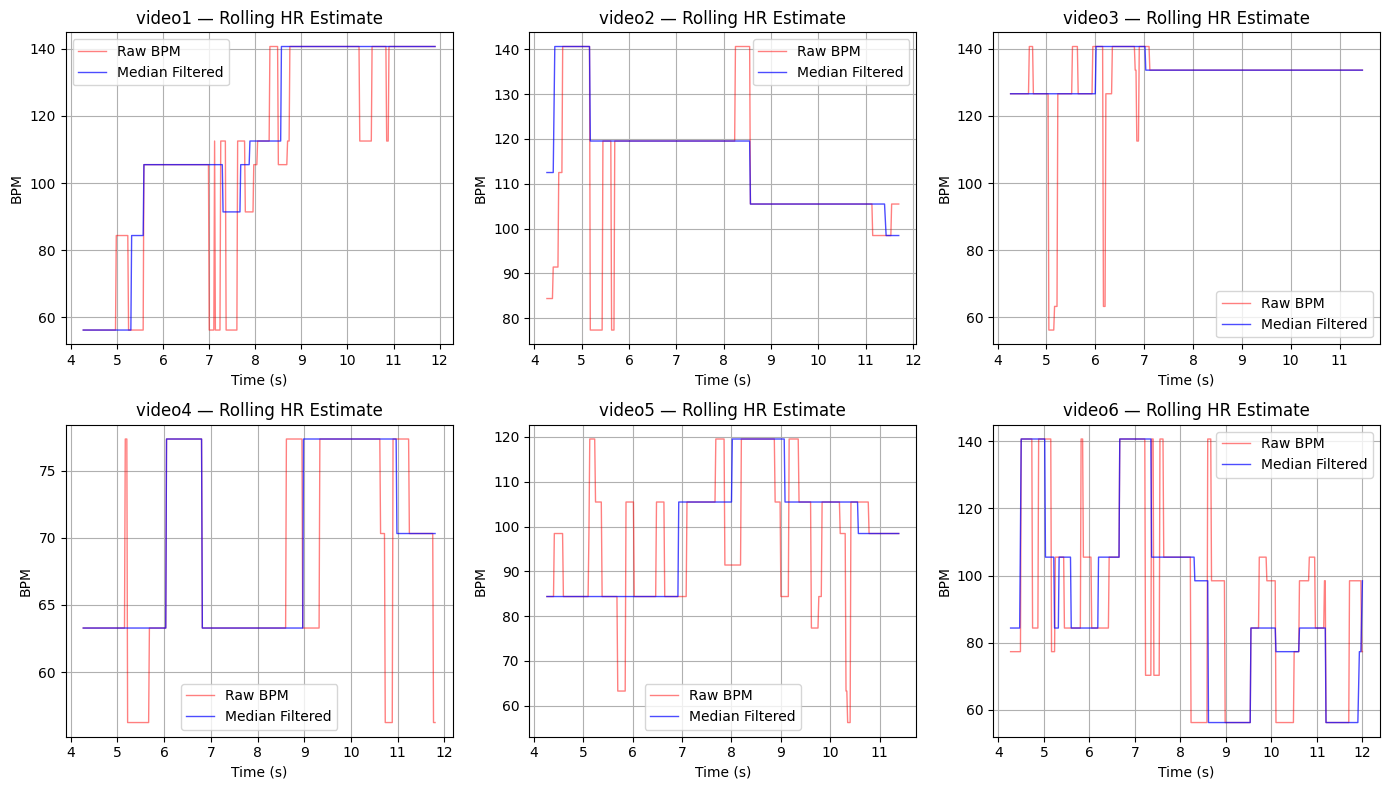

In [ ]:
win_size = 512
rolling_bpm_results = {}   
ica_results = {}

for name, data in video_data.items():
    X = np.column_stack((data["R"], data["G"], data["B"]))
    S_ica = X @ W_global.T   # much faster than ica.transform(X)
    ica_results[name] = S_ica

for name, data in video_data.items():
    X = np.column_stack((data["R"], data["G"], data["B"]))
    # signal = S_ica[:, 0]        # first ICA component
    n = len(data["R"])

    bpm_track = []         
    time_track = []            

    for start in range(0, n - win_size):
        S_ica = X[start : start + win_size] @ W_global.T   
        window = S_ica[:, 0]
        # window = signal[start : start + win_size]

        win = window - np.mean(window)
        fft_vals = np.fft.rfft(win)
        freqs = np.fft.rfftfreq(win_size, d=1/fps)

        # bandpass 
        mask = (freqs >= lowcut) & (freqs <= highcut)
        fft_band = fft_vals * mask

        mag = np.abs(fft_band)
        mag *= mag
        if np.max(mag) != 0:
            mag = mag / np.max(mag)

        peak_idx = np.argmax(mag[1:]) + 1   # skip DC
        peak_freq = freqs[peak_idx]
        bpm = peak_freq * 60.0

        bpm_track.append(bpm)

        # time corresponds to the center of the window
        center_time = (start + win_size/2) / fps
        time_track.append(center_time)

    rolling_bpm_results[name] = (np.array(time_track), np.array(bpm_track))


fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

def median_filter(signal, k=11):
    """
    Simple 1D median filter
    k: window size (odd)
    """
    assert k % 2 == 1, "Window size k must be odd"
    half_k = k // 2
    n = len(signal)
    filtered = np.zeros_like(signal)
    for i in range(n):
        start = max(0, i - half_k)
        end = min(n, i + half_k + 1)
        filtered[i] = np.median(signal[start:end])
    return filtered

for ax, (name, (t_vec, bpm_vec)) in zip(axes, rolling_bpm_results.items()):
    # original plot
    ax.plot(t_vec, bpm_vec, color="red", lw=1, alpha=0.5, label="Raw BPM")
    # median-filtered overlay
    bpm_med = median_filter(bpm_vec, k=61)  # adjust k for smoothing
    ax.plot(t_vec, bpm_med, color="blue", lw=1, alpha=0.7, label="Median Filtered")
    
    ax.set_title(f"{name} — Rolling HR Estimate")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("BPM")
    ax.grid(True)
    ax.legend()

# cleanup empty plots if fewer than 6 videos
for j in range(len(rolling_bpm_results), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
